In [1]:
#Imports & Configurations
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
warnings.filterwarnings("ignore")

#Paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW     = PROJECT_ROOT / "data" / "raw"  / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR  = PROJECT_ROOT / "reports" / "figures"
DATA_PROC.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Color palette ──
CLR = {
    "yes"    : "#E24B4A",   # attrition = left
    "no"     : "#1D9E75",   # attrition = stayed
    "blue"   : "#185FA5",
    "orange" : "#EF9F27",
    "purple" : "#8B5CF6",
    "teal"   : "#0EA5A0",
    "gray"   : "#6B7280",
}
SEQ_RED_GREEN = [CLR["yes"], "#F97316", "#FACC15", CLR["no"]]

plt.rcParams.update({
    "figure.dpi"        : 120,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "axes.grid.axis"    : "y",
    "grid.alpha"        : 0.3,
    "font.size"         : 11,
})

def save_png(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"  ✓  PNG → {path}")

def save_html(fig, name):
    path = FIGURES_DIR / name
    fig.write_html(str(path))
    print(f"  ✓  HTML → {path}")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data exists  : {DATA_RAW.exists()}")

Project root : d:\hr-attrition-predictor
Data exists  : True


In [2]:
#Load Raw Data

df=pd.read_csv(DATA_RAW)

#Dropping columns with zero information value
useless = [c for c in df.columns if df[c].nunique()<=1]
df.drop(columns=useless + ["EmployeeNumber"], inplace=True, errors="ignore")

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(10)

Dataset: 1,470 rows x 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,...,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,...,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,...,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,...,3,2,2,17,3,2,7,7,7,7


In [4]:
#Section 1 -- Interactive Dashboard

#Dashboard - KPI Summary Cards

total=len(df)
left=(df["Attrition"]=="Yes").sum()
rate=left/total*100
avg_income=df["MonthlyIncome"].mean()
avg_tenure=df["YearsAtCompany"].mean()
avg_age=df["Age"].mean()
avg_sat=df[["JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance"]].mean().mean()

fig=make_subplots(
    rows=1, cols=6,
    specs=[[{"type" : "indicator"}]*6]
)

kpis = [
    ("Total Employees",    total,        "",    CLR["blue"]),
    ("Employees Left",     left,         "",    CLR["yes"]),
    ("Attrition Rate",     round(rate,1),"%" ,  CLR["orange"]),
    ("Avg Monthly Income", round(avg_income),"$",CLR["teal"]),
    ("Avg Age",            round(avg_age,1),"y", CLR["purple"]),
    ("Avg Tenure",         round(avg_tenure,1),"y",CLR["gray"]),
]

for i, (label, val, suffix, color) in enumerate(kpis, 1):
    fig.add_trace(
        go.Indicator(
            mode="number",
            value=val,
            number={"suffix": suffix, "font": {"size": 32, "color": color}},
            title={"text": f"<b>{label}</b>", "font": {"size": 12, "color": "#374151"}},
        ),
        row=1, col=i
    )

fig.update_layout(
    height=180,
    margin=dict(t=40, b=10, l=10, r=10),
    paper_bgcolor="white",
    title_text="<b>HR Attrition Dashboard — Executive Summary</b>",
    title_font_size=16,
)
save_html(fig, "week2_01_kpi_cards.html")
fig.show()



  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_01_kpi_cards.html


In [5]:
#Dashboard -- Attrition by Department & Job Role

dept_rate = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Attrition Rate (%)")
      .sort_values("Attrition Rate (%)", ascending=False)
)

role_rate = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Attrition Rate (%)")
      .sort_values("Attrition Rate (%)", ascending=True)
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("<b>Attrition Rate by Department</b>",
                    "<b>Attrition Rate by Job Role</b>"),
    horizontal_spacing=0.12
)

# Department bar
fig.add_trace(
    go.Bar(
        x=dept_rate["Department"],
        y=dept_rate["Attrition Rate (%)"],
        marker_color=[CLR["yes"] if v > rate else CLR["blue"]
                      for v in dept_rate["Attrition Rate (%)"]],
        text=[f"{v:.1f}%" for v in dept_rate["Attrition Rate (%)"]],
        textposition="outside",
        showlegend=False,
    ),
    row=1, col=1
)

# Job Role horizontal bar
fig.add_trace(
    go.Bar(
        y=role_rate["JobRole"],
        x=role_rate["Attrition Rate (%)"],
        orientation="h",
        marker_color=[CLR["yes"] if v > rate else CLR["blue"]
                      for v in role_rate["Attrition Rate (%)"]],
        text=[f"{v:.1f}%" for v in role_rate["Attrition Rate (%)"]],
        textposition="outside",
        showlegend=False,
    ),
    row=1, col=2
)

# Overall average reference line
for col in [1, 2]:
    fig.add_hline(y=rate, line_dash="dash", line_color="gray",
                  annotation_text=f"Avg {rate:.1f}%",
                  annotation_position="top right", row=1, col=col) \
        if col == 1 else \
    fig.add_vline(x=rate, line_dash="dash", line_color="gray",
                  annotation_text=f"Avg {rate:.1f}%",
                  annotation_position="top right", row=1, col=col)

fig.update_layout(
    height=420, paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(t=60, b=40, l=20, r=20),
    yaxis2=dict(tickfont=dict(size=10))
)
fig.update_yaxes(title_text="Attrition Rate (%)", row=1, col=1)
fig.update_xaxes(title_text="Attrition Rate (%)", row=1, col=2)

save_html(fig, "week2_02_dept_role_attrition.html")
fig.show()

  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_02_dept_role_attrition.html


In [6]:
#Dashboard -- Monthly Income Analysis

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("<b>Income Distribution by Attrition</b>",
                    "<b>Income by Job Level & Attrition</b>"),
    horizontal_spacing=0.1
)

for label, color in [("Yes", CLR["yes"]), ("No", CLR["no"])]:
    subset = df[df["Attrition"] == label]["MonthlyIncome"]
    fig.add_trace(
        go.Violin(
            x=[label] * len(subset),
            y=subset,
            name=f"Attrition={label}",
            box_visible=True,
            meanline_visible=True,
            fillcolor=color,
            line_color=color,
            opacity=0.7,
        ),
        row=1, col=1
    )

for label, color in [("Yes", CLR["yes"]), ("No", CLR["no"])]:
    subset = df[df["Attrition"] == label]
    fig.add_trace(
        go.Box(
            x=subset["JobLevel"],
            y=subset["MonthlyIncome"],
            name=f"Attrition={label}",
            marker_color=color,
            boxmean=True,
            showlegend=(label == "Yes"),
        ),
        row=1, col=2
    )

fig.update_layout(
    height=420, paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(t=60, b=40),
    legend=dict(title="Attrition", x=0.72, y=0.98),
    violingap=0.3,
)
fig.update_yaxes(title_text="Monthly Income ($)", row=1, col=1)
fig.update_yaxes(title_text="Monthly Income ($)", row=1, col=2)
fig.update_xaxes(title_text="Job Level", row=1, col=2)

save_html(fig, "week2_03_income_analysis.html")
fig.show()

  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_03_income_analysis.html


  ✓  PNG → d:\hr-attrition-predictor\reports\figures\week2_04_satisfaction_heatmap.png


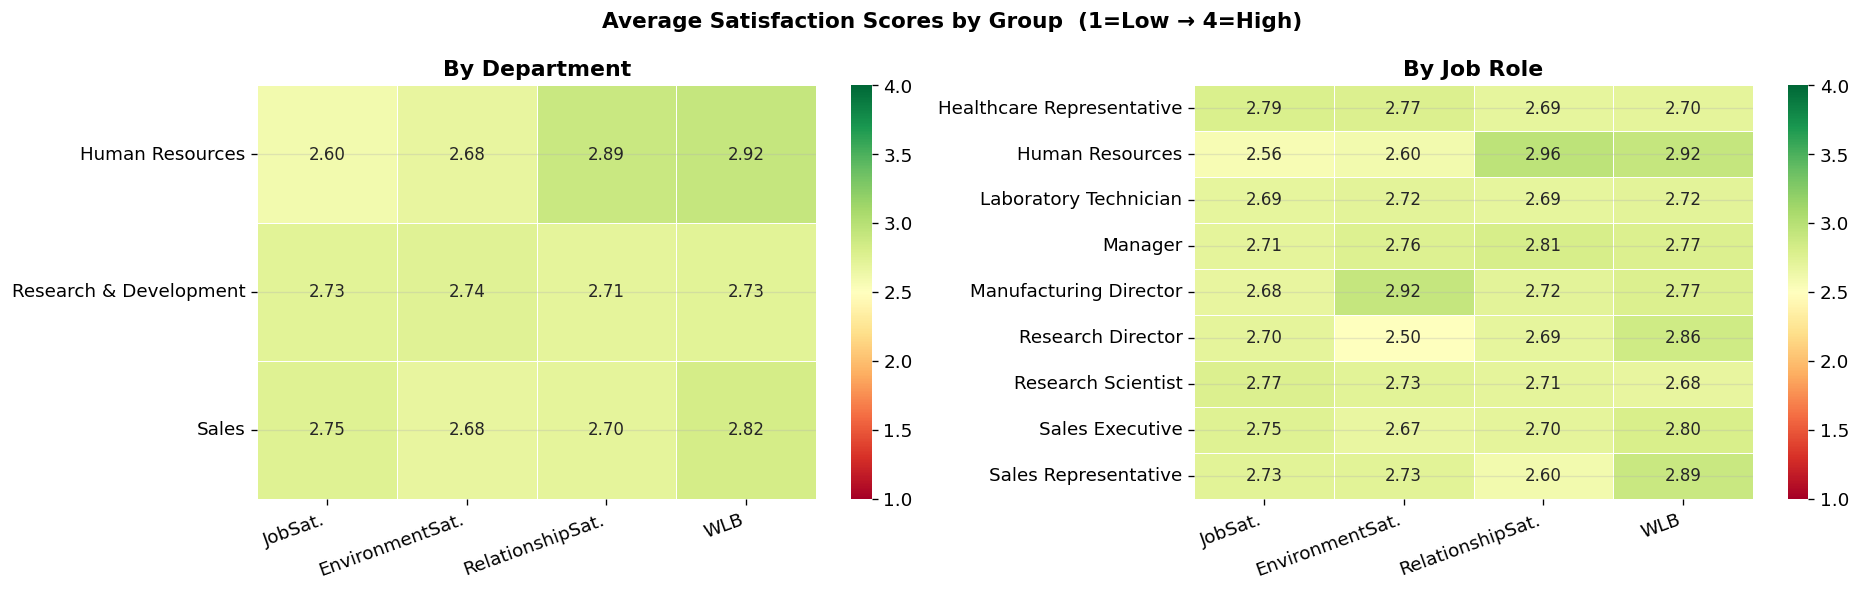

In [7]:
#Dashboard -- Satisfaction Heatmap (Seaborn -- Clearer for grids)
sat_cols   = ["JobSatisfaction", "EnvironmentSatisfaction",
              "RelationshipSatisfaction", "WorkLifeBalance"]
dept_sat   = df.groupby("Department")[sat_cols].mean().round(2)
role_sat   = df.groupby("JobRole")[sat_cols].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Average Satisfaction Scores by Group  (1=Low → 4=High)",
             fontsize=13, fontweight="bold")

for ax, data, title in zip(axes, [dept_sat, role_sat],
                            ["By Department", "By Job Role"]):
    sns.heatmap(
        data, annot=True, fmt=".2f",
        cmap="RdYlGn", vmin=1, vmax=4,
        linewidths=0.5, ax=ax,
        annot_kws={"size": 10}
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(
        [c.replace("Satisfaction","Sat.").replace("WorkLifeBalance","WLB")
         for c in sat_cols],
        rotation=20, ha="right"
    )
    ax.set_ylabel("")

plt.tight_layout()
save_png(fig, "week2_04_satisfaction_heatmap.png")
plt.show()

In [8]:
#Dashboard - Age V Income Scatter (Interactive)

fig = px.scatter(
    df,
    x="Age",
    y="MonthlyIncome",
    color="Attrition",
    color_discrete_map={"Yes": CLR["yes"], "No": CLR["no"]},
    size="TotalWorkingYears",
    hover_data=["JobRole", "Department", "JobLevel", "YearsAtCompany"],
    opacity=0.65,
    title="<b>Age vs Monthly Income — Colored by Attrition</b><br>"
          "<sub>Bubble size = Total Working Years</sub>",
    labels={"MonthlyIncome": "Monthly Income ($)", "Age": "Age (years)"}
)
fig.update_layout(
    height=480, paper_bgcolor="white", plot_bgcolor="#F9FAFB",
    legend=dict(title="Attrition"),
    margin=dict(t=80, b=40)
)
fig.update_xaxes(showgrid=True, gridcolor="#E5E7EB")
fig.update_yaxes(showgrid=True, gridcolor="#E5E7EB")

save_html(fig, "week2_05_age_income_scatter.html")
fig.show()

  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_05_age_income_scatter.html
